# LSTM 학습

주문 시퀀스로 `LSTM`을 학습하고 결과를 바로 확인합니다.

In [1]:
%matplotlib inline

import os
import random
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, confusion_matrix, f1_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight

try:
    import tensorflow as tf
except ImportError as exc:
    raise ImportError('tensorflow가 없습니다. venv 커널을 선택하세요.') from exc

print(sys.executable)
print(tf.__version__)

X_PATH = 'outputs/X_seq.npy'
Y_PATH = 'outputs/y.npy'
MODEL_PATH = 'outputs/lstm_model.keras'
METRIC_PATH = 'outputs/lstm_metrics.csv'
RANDOM_SEED = 42
TEST_SIZE = 0.2
VAL_SIZE = 0.2
EPOCHS = 20
BATCH_SIZE = 256

/Users/jsh/Desktop/class/3-1/딥러닝응용/고빈도 고객 재구매 지연 위험 예측/venv/bin/python
2.21.0


In [2]:
def set_seed(seed: int = RANDOM_SEED):
    # 시드 고정
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)


def resolve_path(path_text: str) -> Path:
    # 경로 확인
    candidates = [Path(path_text), Path(Path(path_text).name)]
    for path in candidates:
        if path.exists():
            return path
    raise FileNotFoundError(f'파일을 찾을 수 없습니다: {path_text}')


def load_data():
    # 데이터 불러오기
    x_seq = np.load(resolve_path(X_PATH)).astype(np.float32)
    y = np.load(resolve_path(Y_PATH)).astype(np.int32)
    print(f'[INFO] X_seq shape: {x_seq.shape}')
    print(f'[INFO] y shape: {y.shape}')
    print(f'[INFO] 라벨 분포: {np.bincount(y)}')
    return x_seq, y


def split_data(x_seq: np.ndarray, y: np.ndarray):
    # 데이터 분할
    sample_id = np.arange(len(y))
    train_idx, test_idx, y_train, y_test = train_test_split(
        sample_id, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_SEED
    )
    val_ratio = VAL_SIZE / (1.0 - TEST_SIZE)
    train_idx, val_idx, y_train, y_val = train_test_split(
        train_idx, y_train, test_size=val_ratio, stratify=y_train, random_state=RANDOM_SEED
    )

    scaler = StandardScaler()
    x_train = x_seq[train_idx]
    x_val = x_seq[val_idx]
    x_test = x_seq[test_idx]
    x_train = scaler.fit_transform(x_train.reshape(-1, x_train.shape[-1])).reshape(x_train.shape)
    x_val = scaler.transform(x_val.reshape(-1, x_val.shape[-1])).reshape(x_val.shape)
    x_test = scaler.transform(x_test.reshape(-1, x_test.shape[-1])).reshape(x_test.shape)

    class_values = np.unique(y_train)
    weights = compute_class_weight(class_weight='balanced', classes=class_values, y=y_train)
    class_weight = {int(c): float(w) for c, w in zip(class_values, weights)}
    print(f'[INFO] 학습 데이터 크기: {x_train.shape}')
    print(f'[INFO] 검증 데이터 크기: {x_val.shape}')
    print(f'[INFO] 테스트 데이터 크기: {x_test.shape}')
    return x_train, x_val, x_test, y_train, y_val, y_test, class_weight


def build_model(input_shape):
    # 모델 정의
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),
        tf.keras.layers.LSTM(64),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.Dense(1, activation='sigmoid'),
    ])
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')],
    )
    return model


class ProgressCallback(tf.keras.callbacks.Callback):
    # 진행 로그
    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        print(
            f"epoch {epoch + 1:02d} | loss {logs.get('loss', 0):.4f} | "
            f"acc {logs.get('accuracy', 0):.4f} | auc {logs.get('auc', 0):.4f} | "
            f"val_loss {logs.get('val_loss', 0):.4f} | val_auc {logs.get('val_auc', 0):.4f}"
        )


def evaluate_model(model, x_test: np.ndarray, y_test: np.ndarray):
    # 성능 평가
    prob = model.predict(x_test, verbose=0).ravel()
    pred = (prob >= 0.5).astype(int)
    return {
        'accuracy': accuracy_score(y_test, pred),
        'precision': precision_score(y_test, pred, zero_division=0),
        'recall': recall_score(y_test, pred, zero_division=0),
        'f1': f1_score(y_test, pred, zero_division=0),
        'roc_auc': roc_auc_score(y_test, prob),
        'confusion_matrix': confusion_matrix(y_test, pred),
    }

[INFO] X_seq shape: (43890, 5, 10)
[INFO] y shape: (43890,)
[INFO] 라벨 분포: [42464  1426]
[INFO] 학습 데이터 크기: (26334, 5, 10)
[INFO] 검증 데이터 크기: (8778, 5, 10)
[INFO] 테스트 데이터 크기: (8778, 5, 10)


epoch 01 | loss 0.6147 | acc 0.5331 | auc 0.7119 | val_loss 0.6011 | val_auc 0.7450


epoch 02 | loss 0.5950 | acc 0.5905 | auc 0.7385 | val_loss 0.5903 | val_auc 0.7509


epoch 03 | loss 0.5896 | acc 0.6151 | auc 0.7437 | val_loss 0.5810 | val_auc 0.7538


epoch 04 | loss 0.5864 | acc 0.6267 | auc 0.7468 | val_loss 0.5829 | val_auc 0.7541


...

epoch 12 | loss 0.5772 | acc 0.6579 | auc 0.7611 | val_loss 0.5906 | val_auc 0.7583


epoch 13 | loss 0.5737 | acc 0.6715 | auc 0.7611 | val_loss 0.5879 | val_auc 0.7579


epoch 14 | loss 0.5737 | acc 0.6720 | auc 0.7629 | val_loss 0.5882 | val_auc 0.7560


epoch 15 | loss 0.5722 | acc 0.6803 | auc 0.7625 | val_loss 0.5955 | val_auc 0.7559


,accuracy,precision,recall,f1,roc_auc
0,0.643655,0.062211,0.708772,0.114383,0.749399


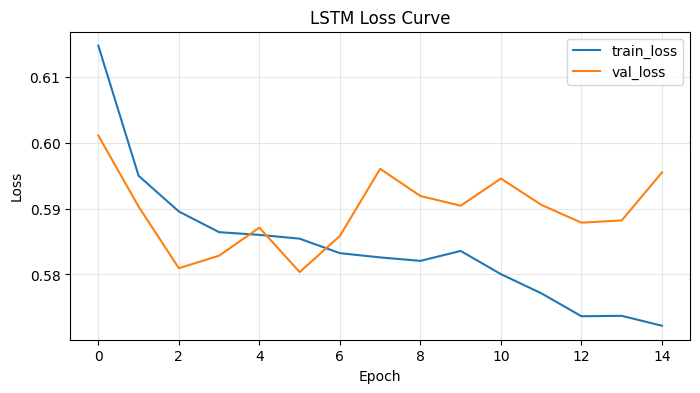

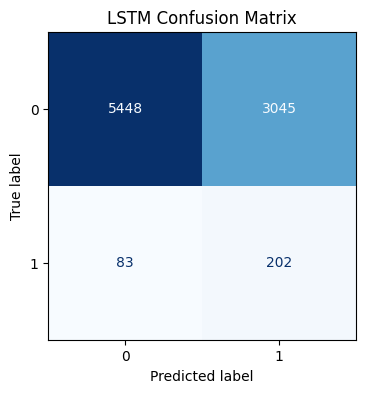

In [3]:
# 실행
set_seed()
x_seq, y = load_data()
x_train, x_val, x_test, y_train, y_val, y_test, class_weight = split_data(x_seq, y)
model = build_model((x_train.shape[1], x_train.shape[2]))

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_auc', mode='max', patience=4, restore_best_weights=True),
    ProgressCallback(),
]

history = model.fit(
    x_train,
    y_train,
    validation_data=(x_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weight,
    callbacks=callbacks,
    verbose=0,
)

metrics = evaluate_model(model, x_test, y_test)
model.save(MODEL_PATH)
pd.DataFrame([{k: v for k, v in metrics.items() if k != 'confusion_matrix'}]).to_csv(METRIC_PATH, index=False)
display(pd.DataFrame([{k: v for k, v in metrics.items() if k != 'confusion_matrix'}]))

plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('LSTM Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(metrics['confusion_matrix']).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('LSTM Confusion Matrix')
plt.show()